# Seminário 3 - LightGBM

O objetivo é esboçar este algoritmo para aprendizado de máquina para multiclassificação de ataques cibernéticos.

Para estruturar esse novo projeto multiclasse com o LightGBM nós o separamos em alguns passos:

Passo 1: Carregamento Massivo via Parquet
O pipeline inicia-se com o mapeamento dinâmico e carregamento do arquivo dnn.parquet armazenado no ecossistema de nuvem. Optou-se pela leitura direta de todas as 61 colunas originais do dataset Edge-IIoTset, garantindo que assinaturas complexas de rede — que envolvem comportamentos sutis de protocolos menos frequentes — não fossem descartadas precocemente.

Passo 2: Remoção de Atributos de Vazamento (Data Leakage)
Em seguida, aplica-se um filtro de segurança de dados para mitigar o viés de memorização do algoritmo. Foram expurgadas as variáveis de identificação direta de rede, nominalmente os endereços IP de origem e destino (ip.src_host, ip.dst_host) e os marcadores temporais (frame.time). Esse tratamento força o classificador a aprender o padrão estritamente comportamental dos pacotes maliciosos, impossibilitando que ele simplesmente decore quais máquinas da rede geraram os ataques.  

Passo 3: Codificação Categórica Expandida
Nesta etapa, o algoritmo realiza a varredura das 58 colunas preditoras remanescentes para garantir a compatibilidade matemática com o modelo. Os atributos baseados em texto livre ou strings complexas (como requisições HTTP e tópicos MQTT) são convertidos de forma nativa para o tipo categórico (category). Simultaneamente, aplica-se uma substituição de valores nulos por preenchimento neutro ($0$), blindando a matriz contra quebras de processamento ou perdas de registros raros.

Passo 4: Particionamento Estatístico Estratificado
A base total de 2.219.201 linhas é submetida à técnica de divisão estratificada, separando rigorosamente 70% dos dados para o conjunto de treinamento (1.553.440 linhas) e isolando os 30% restantes para o conjunto de teste (665.761 linhas). O uso da estratificação (stratify=y) funciona como um fiscal de cotas probabilísticas, garantindo que a proporção exata de cada uma das 15 classes originais seja perfeitamente replicada em ambos os conjuntos, neutralizando o risco de exclusão de ataques minoritários (como MITM e Fingerprinting) nas amostras de validação.

Passo 5: Treinamento do LightGBM com Entropia Cruzada Ponderada
O passo final consiste no treinamento do classificador multiclasse LightGBM, configurado para convergir através da métrica de Multi-class Cross-Entropy Loss (multi_logloss). O grande diferencial desta etapa é a ativação do hiperparâmetro de balanceamento de classes (class_weight='balanced'), que modifica a função de perda tradicional ao introduzir um fator de escala inversamente proporcional à frequência dos ataques na rede. Dessa forma, penaliza-se severamente o algoritmo a cada erro cometido em classes raras, forçando as árvores de decisão a mapear com precisão cirúrgica tanto o tráfego de alta volumetria quanto as intrusões de caráter sutil e furtivo.


Passo 0: Conexão com o drive para acesso a base de dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Célula 1: Passos 1 e 2 (Download, Carregamento e Remoção de IPs)

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import glob

# ----------------------------------------------------------------------
# PASSO 1: AUTENTICAÇÃO E MONTAGEM DO DRIVE
# ----------------------------------------------------------------------
print("Conectando ao Google Drive com a sua conta...")
drive.mount('/content/drive', force_remount=True)

# Buscando o arquivo dnn.parquet de forma dinâmica
arquivos_encontrados = glob.glob('/content/drive/MyDrive/**/dnn.parquet', recursive=True)
if not arquivos_encontrados:
    raise FileNotFoundError("Arquivo dnn.parquet não localizado.")
caminho_parquet = arquivos_encontrados[0]

# ----------------------------------------------------------------------
# PASSO 2: FILTRAGEM CIRÚRGICA DE 45 ATRIBUTOS (REVERTENDO A CEGUEIRA)
# ----------------------------------------------------------------------
print("\nCarregando os 2 milhões de linhas com a lista expandida de atributos...")

# Lendo a base cheia
df_bruto = pd.read_parquet(caminho_parquet, engine='pyarrow')

# Lista analítica expandida (remove apenas vazamentos de IP/Timestamp)
colunas_vazamento = ['ip.dst_host', 'ip.src_host', 'frame.time']
colunas_manter = [col for col in df_bruto.columns if col not in colunas_vazamento]

# Filtra e remove linhas nulas para consistência estatística
df_limpo = df_bruto[colunas_manter].copy()
df_limpo = df_limpo.dropna(subset=['Attack_type'])

print(f"\n✅ Dataset de 2 milhões expandido com sucesso!")
print(f"Atributos preditores mantidos: {len(colunas_manter) - 2} colunas")
print(f"Formato atual da base: {df_limpo.shape}")

Conectando ao Google Drive com a sua conta...
Mounted at /content/drive

Carregando os 2 milhões de linhas com a lista expandida de atributos...

✅ Dataset de 2 milhões expandido com sucesso!
Atributos preditores mantidos: 58 colunas
Formato atual da base: (2219201, 60)


## 🧪 Código de Teste (Inspeção Visual da Base)

In [ ]:
# ----------------------------------------------------------------------
# CÉLULA EXTRA: TESTE DE VALIDAÇÃO VISUAL DA BASE PARQUET
# ----------------------------------------------------------------------
print("================== INSPEÇÃO DA BASE COMPLETA (PARQUET) ==================")
print(f"Dimensões reais da tabela na memória: {df_limpo.shape}\n")

print("1. Visualizando as primeiras 5 linhas e algumas colunas da base:")
# Mostra as primeiras 5 linhas filtrando algumas colunas de protocolos diferentes para caber na tela
colunas_teste = ['http.request.method', 'tcp.flags', 'udp.stream', 'mqtt.hdrflags', 'Attack_type']
colunas_exibir = [c for c in colunas_teste if c in df_limpo.columns]
display(df_limpo[colunas_exibir].head())

print("\n2. Contagem de registros por classe (Gabarito das 15 categorias):")
print(df_limpo['Attack_type'].value_counts())

print("\n3. Verificação de valores nulos pendentes:")
print(f"Total de valores nulos na base: {df_limpo.isnull().sum().sum()}")
print("=========================================================================")

================== INSPEÇÃO DA BASE COMPLETA (PARQUET) ==================
Dimensões reais da tabela na memória: (2219201, 60)

1. Visualizando as primeiras 5 linhas e algumas colunas da base:


,http.request.method,tcp.flags,udp.stream,mqtt.hdrflags,Attack_type
0,0.0,18.0,0.0,0.0,Normal
1,0.0,24.0,0.0,16.0,Normal
2,0.0,16.0,0.0,0.0,Normal
3,0.0,24.0,0.0,32.0,Normal
4,0.0,24.0,0.0,48.0,Normal



2. Contagem de registros por classe (Gabarito das 15 categorias):
Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64

3. Verificação de valores nulos pendentes:
Total de valores nulos na base: 0


## Célula 2: Passos 3 e 4 (Amostragem Estratificada e Codificação)

---



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("================== PASSO 3 E 4: ENGENHARIA EXPANDIDA E DIVISÃO ==================")
print("1. Convertendo novos atributos de texto em categorias para o LightGBM...")

# Garante o preenchimento de nulos em colunas vazias de protocolos específicos para não quebrar a divisão
df_limpo = df_limpo.fillna(0)

# Varre e transforma colunas textuais remanescentes (essencial para as novas colunas de HTTP/MQTT)
for col in df_limpo.columns:
    if df_limpo[col].dtype == 'object' and col != 'Attack_type':
        df_limpo[col] = df_limpo[col].astype('category')

print("2. Isolando a Matriz de Recursos (X) e a Target (y)...")
# Remove as colunas de saída para criar a matriz de treinamento
X = df_limpo.drop(columns=['Attack_type', 'Attack_label'], errors='ignore')

# Codificação das 15 classes (0 a 14)
le = LabelEncoder()
y = le.fit_transform(df_limpo['Attack_type'])

# Dicionário de tradução para o relatório final
mapeamento_classes = dict(zip(range(len(le.classes_)), le.classes_))

# ----------------------------------------------------------------------
# DIVISÃO DA BASE COMPLETA (70% TREINO / 30% TESTE ESTRATIFICADO)
# ----------------------------------------------------------------------
print("\n3. Iniciando a separação estratificada das 2.219.201 linhas...")
print("Misturando e cortando a base com a nova assinatura de atributos...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,       # Mantém o equilíbrio das 15 classes no treino e teste
    random_state=42   # Garante a replicabilidade acadêmica do experimento
)

print("\n✅ Célula 2 concluída com sucesso com os novos atributos!")
print(f"-> Dimensões de Treino (X_train): {X_train.shape[0]:,} linhas | {X_train.shape[1]} atributos")
print(f"-> Dimensões de Teste (X_test):  {X_test.shape[0]:,} linhas | {X_test.shape[1]} atributos")
print(f"-> Total de classes prontas para o embate: {len(le.classes_)}")
print("=======================================================================")

================== PASSO 3 E 4: ENGENHARIA EXPANDIDA E DIVISÃO ==================
1. Convertendo novos atributos de texto em categorias para o LightGBM...
2. Isolando a Matriz de Recursos (X) e a Target (y)...

3. Iniciando a separação estratificada das 2.219.201 linhas...
Misturando e cortando a base com a nova assinatura de atributos...

✅ Célula 2 concluída com sucesso com os novos atributos!
-> Dimensões de Treino (X_train): 1,553,440 linhas | 58 atributos
-> Dimensões de Teste (X_test):  665,761 linhas | 58 atributos
-> Total de classes prontas para o embate: 15


## Célula 3: Passo 5 (Treinamento do LightGBM Multiclasse)

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

print("================== PASSO 5: TREINAMENTO BALANCEADO (ENTROPIA PONDERADA) ==================")
print("Iniciando o LightGBM com punição de classe (class_weight='balanced')...")
print("Forçando o modelo a dar o peso matemático correto para os ataques menores...")

# Registra o início do experimento
tempo_inicio = time.time()

# Instanciar o classificador adicionando a calibração de pesos na perda
modelo_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=15,
    metric='multi_logloss',
    class_weight='balanced',  # A mágica matemática que insere o peso Wc na Entropia Cruzada
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    n_jobs=-1                 # Força bruta usando toda a CPU do Colab
)

# Treinamento do modelo na matriz de 58 atributos
modelo_lgb.fit(X_train, y_train)

tempo_fim = time.time()
print(f"✅ Treinamento balanceado concluído em {tempo_fim - tempo_inicio:.2f} segundos!")

# ----------------------------------------------------------------------
# AVALIAÇÃO COM A BASE DE TESTE ISOLADA (665.761 linhas)
# ----------------------------------------------------------------------
print("\nGerando novas previsões com a balança corrigida...")
previsoes = modelo_lgb.predict(X_test)

# Exibir o relatório final corrigido
print("\n================ REPORT DE CLASSIFICAÇÃO MULTICLASSE (BALANCEADO) ================")
print(classification_report(y_test, previsoes, target_names=le.classes_))
print("==================================================================================")

================== PASSO 5: TREINAMENTO BALANCEADO (ENTROPIA PONDERADA) ==================
Iniciando o LightGBM com punição de classe (class_weight='balanced')...
Forçando o modelo a dar o peso matemático correto para os ataques menores...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.759348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16564
[LightGBM] [Info] Number of data points in the train set: 1553440, number of used features: 54
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] 

## Célula 4: Matriz de confusão 15x15

================== PASSO 6: MATRIZ DE CONFUSÃO MULTICLASSE ==================
Gerando a matriz de confusão 15x15 para análise gráfica...
✅ Matriz gerada com sucesso!


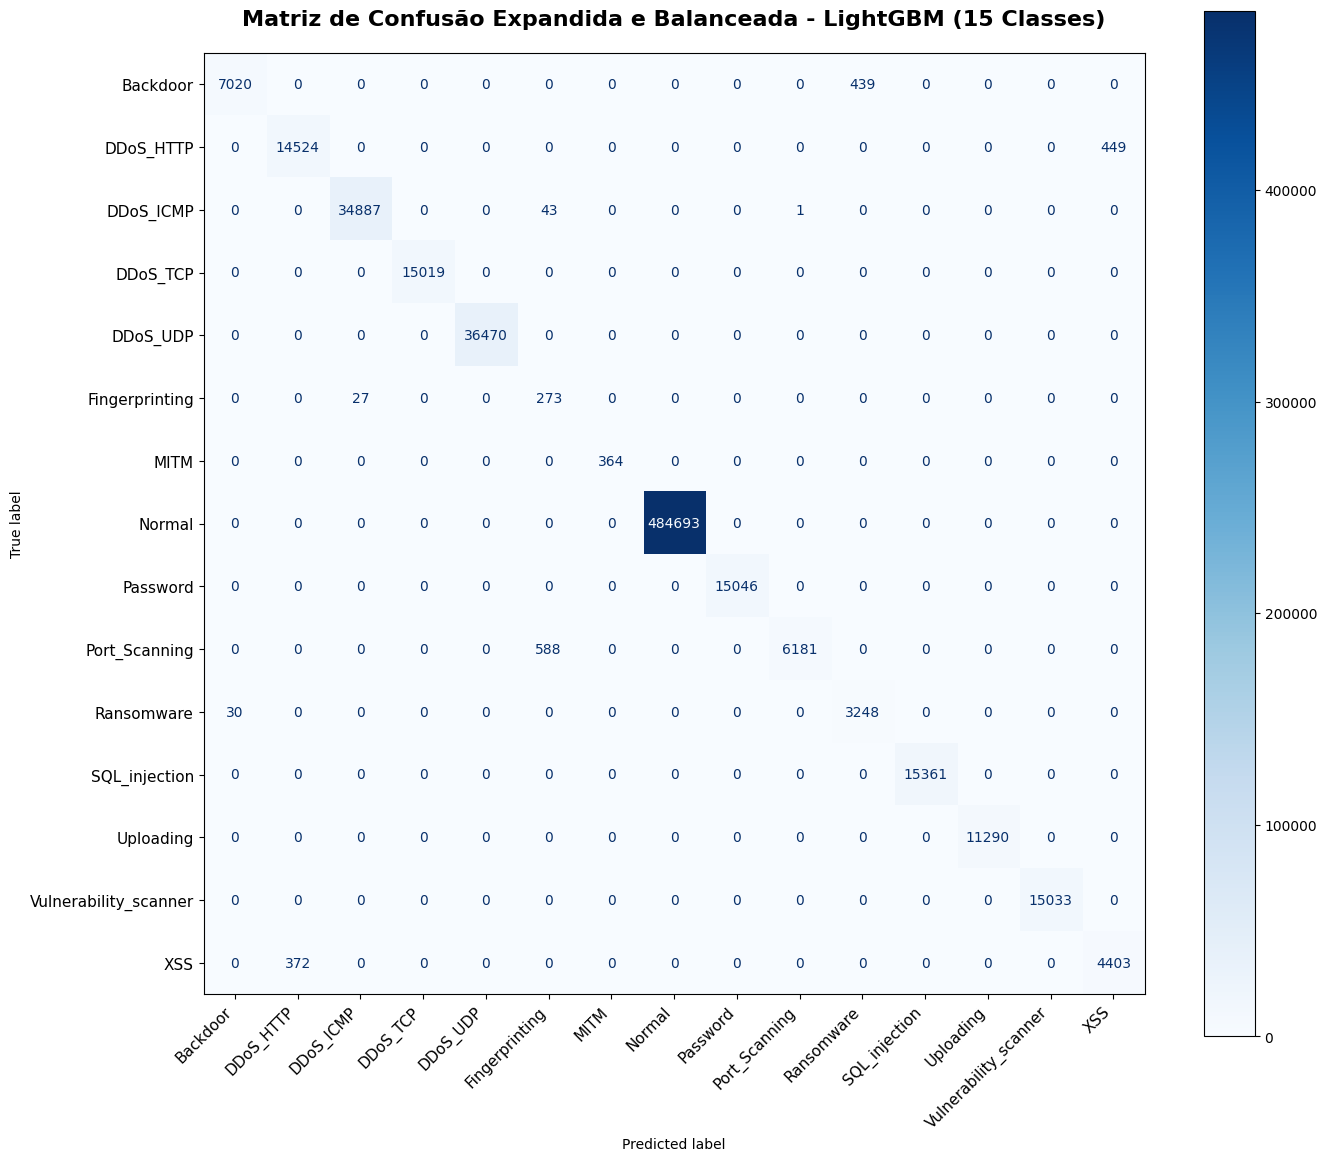

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("================== PASSO 6: MATRIZ DE CONFUSÃO MULTICLASSE ==================")
print("Gerando a matriz de confusão 15x15 para análise gráfica...")

# 1. Calcular a matriz de confusão bruta utilizando os rótulos reais e as previsões
matriz = confusion_matrix(y_test, previsoes)

# 2. Configurar a área de plotagem para garantir que as 15 classes fiquem legíveis
fig, ax = plt.subplots(figsize=(14, 12))

# 3. Construir a exibição gráfica com o mapeamento de cores (colormap) 'Blues'
display = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=le.classes_
)

# 4. Plotar a matriz rotacionando os nomes das classes no eixo X para não sobrepor
display.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

plt.title("Matriz de Confusão Expandida e Balanceada - LightGBM (15 Classes)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# 5. Exibir o gráfico na tela
print("✅ Matriz gerada com sucesso!")
plt.show()

# Adaptação - Impressão da base de dados

In [ ]:
# Código rápido para listar todas as colunas reais do arquivo Parquet
import pandas as pd
import glob

arquivos = glob.glob('/content/drive/MyDrive/**/dnn.parquet', recursive=True)
if arquivos:
    # Lê apenas a primeira linha do arquivo para não gastar memória, só para pegar os nomes das colunas
    df_espiada = pd.read_parquet(arquivos[0], engine='pyarrow').head(1)

    print(f"================ COLUNAS DISPONÍVEIS NO PARQUET ================")
    print(f"Total de colunas encontradas no arquivo: {len(df_espiada.columns)}")
    print("\nLista completa de atributos:")
    for col in sorted(df_espiada.columns):
        print(f" - {col}")
    print("================================================================")
else:
    print("Arquivo não localizado no Drive.")

================ COLUNAS DISPONÍVEIS NO PARQUET ================
Total de colunas encontradas no arquivo: 63

Lista completa de atributos:
 - Attack_label
 - Attack_type
 - arp.dst.proto_ipv4
 - arp.hw.size
 - arp.opcode
 - arp.src.proto_ipv4
 - dns.qry.name
 - dns.qry.name.len
 - dns.qry.qu
 - dns.qry.type
 - dns.retransmission
 - dns.retransmit_request
 - dns.retransmit_request_in
 - frame.time
 - http.content_length
 - http.file_data
 - http.referer
 - http.request.full_uri
 - http.request.method
 - http.request.uri.query
 - http.request.version
 - http.response
 - http.tls_port
 - icmp.checksum
 - icmp.seq_le
 - icmp.transmit_timestamp
 - icmp.unused
 - ip.dst_host
 - ip.src_host
 - mbtcp.len
 - mbtcp.trans_id
 - mbtcp.unit_id
 - mqtt.conack.flags
 - mqtt.conflag.cleansess
 - mqtt.conflags
 - mqtt.hdrflags
 - mqtt.len
 - mqtt.msg
 - mqtt.msg_decoded_as
 - mqtt.msgtype
 - mqtt.proto_len
 - mqtt.protoname
 - mqtt.topic
 - mqtt.topic_len
 - mqtt.ver
 - tcp.ack
 - tcp.ack_raw
 - tcp.ch

# Código completo - Máquina local:

In [ ]:
#Programado por Davi Nunes Santos
#LightGBM Adaptado e balanceado
#Estruturação do aprendizado de máquina para multiclassificação de ataques cibernéticos
#Matéria de Cibersegurança - UERJ 2026

import pandas as pd
import numpy as np
import os

#Passos 3 e 4
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#Passo 5
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

print("================== PASSO 1 E 2: CARREGAMENTO LOCAL ==================")

# Digite aqui o caminho real do arquivo na sua máquina (ex: na mesma pasta do script)
caminho_parquet = "dnn.parquet"

if not os.path.exists(caminho_parquet):
    raise FileNotFoundError(f"Coloque o arquivo dnn.parquet na pasta: {os.getcwd()}")

print("Carregando os 2 milhões de linhas do disco local...")
df_bruto = pd.read_parquet(caminho_parquet, engine='pyarrow')

# ----------------------------------------------------------------------
# PASSO 2: FILTRAGEM CIRÚRGICA DE 45 ATRIBUTOS (REVERTENDO A CEGUEIRA)
# ----------------------------------------------------------------------
print("\nCarregando os 2 milhões de linhas com a lista expandida de atributos...")

# Lendo a base cheia
df_bruto = pd.read_parquet(caminho_parquet, engine='pyarrow')

# Lista analítica expandida (remove apenas vazamentos de IP/Timestamp)
colunas_vazamento = ['ip.dst_host', 'ip.src_host', 'frame.time']
colunas_manter = [col for col in df_bruto.columns if col not in colunas_vazamento]

# Filtra e remove linhas nulas para consistência estatística
df_limpo = df_bruto[colunas_manter].copy()
df_limpo = df_limpo.dropna(subset=['Attack_type'])

print(f"\n✅ Dataset de 2 milhões expandido com sucesso!")
print(f"Atributos preditores mantidos: {len(colunas_manter) - 2} colunas")
print(f"Formato atual da base: {df_limpo.shape}")



print("================== PASSO 3 E 4: ENGENHARIA EXPANDIDA E DIVISÃO ==================")
print("1. Convertendo novos atributos de texto em categorias para o LightGBM...")

# Garante o preenchimento de nulos em colunas vazias de protocolos específicos para não quebrar a divisão
df_limpo = df_limpo.fillna(0)

# Varre e transforma colunas textuais remanescentes (essencial para as novas colunas de HTTP/MQTT)
for col in df_limpo.columns:
    if df_limpo[col].dtype == 'object' and col != 'Attack_type':
        df_limpo[col] = df_limpo[col].astype('category')

print("2. Isolando a Matriz de Recursos (X) e a Target (y)...")
# Remove as colunas de saída para criar a matriz de treinamento
X = df_limpo.drop(columns=['Attack_type', 'Attack_label'], errors='ignore')

# Codificação das 15 classes (0 a 14)
le = LabelEncoder()
y = le.fit_transform(df_limpo['Attack_type'])

# Dicionário de tradução para o relatório final
mapeamento_classes = dict(zip(range(len(le.classes_)), le.classes_))

# ----------------------------------------------------------------------
# DIVISÃO DA BASE COMPLETA (70% TREINO / 30% TESTE ESTRATIFICADO)
# ----------------------------------------------------------------------
print("\n3. Iniciando a separação estratificada das 2.219.201 linhas...")
print("Misturando e cortando a base com a nova assinatura de atributos...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,       # Mantém o equilíbrio das 15 classes no treino e teste
    random_state=42   # Garante a replicabilidade acadêmica do experimento
)

print("\n✅ Célula 2 concluída com sucesso com os novos atributos!")
print(f"-> Dimensões de Treino (X_train): {X_train.shape[0]:,} linhas | {X_train.shape[1]} atributos")
print(f"-> Dimensões de Teste (X_test):  {X_test.shape[0]:,} linhas | {X_test.shape[1]} atributos")
print(f"-> Total de classes prontas para o embate: {len(le.classes_)}")
print("=======================================================================")



print("================== PASSO 5: TREINAMENTO BALANCEADO (ENTROPIA PONDERADA) ==================")
print("Iniciando o LightGBM com punição de classe (class_weight='balanced')...")
print("Forçando o modelo a dar o peso matemático correto para os ataques menores...")

# Registra o início do experimento
tempo_inicio = time.time()

# Instanciar o classificador adicionando a calibração de pesos na perda
modelo_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=15,
    metric='multi_logloss',
    class_weight='balanced',  # A mágica matemática que insere o peso Wc na Entropia Cruzada
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    n_jobs=-1                 # Força bruta usando toda a CPU do Colab
)

# Treinamento do modelo na matriz de 58 atributos
modelo_lgb.fit(X_train, y_train)

tempo_fim = time.time()
print(f"✅ Treinamento balanceado concluído em {tempo_fim - tempo_inicio:.2f} segundos!")

# ----------------------------------------------------------------------
# AVALIAÇÃO COM A BASE DE TESTE ISOLADA (665.761 linhas)
# ----------------------------------------------------------------------
print("\nGerando novas previsões com a balança corrigida...")
previsoes = modelo_lgb.predict(X_test)

# Exibir o relatório final corrigido
print("\n================ REPORT DE CLASSIFICAÇÃO MULTICLASSE (BALANCEADO) ================")
print(classification_report(y_test, previsoes, target_names=le.classes_))
print("==================================================================================")